# Pattern #4: Multi-Agent Systems — Parallel Specialists

**LangGraph Implementation**

## Overview

Multi-agent systems use specialized agents working **in parallel** via fan-out / fan-in:

```
                         ┌─→ PolicyAgent (RAG) ────┐
Query → Router (intent) ─┼─→ LogisticsAgent (Web) ──┼─→ Judge → Final Answer
                         └─→ BookingLookup (tool) ──┘
```

**Router:** Classifies intent (policy / logistics / booking) and extracts patient identifiers.
The routing function returns a **list** of specialist nodes — LangGraph executes them **in parallel**.

**Specialist Nodes (fan-out, only activated specialists run):**
- **PolicyAgent**: Internal RAG for procedures, guidelines, clinical info
- **LogisticsAgent**: Web search for hours, contacts, operational info
- **BookingLookup**: Looks up patient bookings by name/phone/email

**Judge (fan-in):** Waits for all activated specialists to finish, then merges their results.

This mirrors the from-scratch version's `ThreadPoolExecutor` parallelism — but the graph handles it declaratively.

In [1]:
import sys
import json
import re
from pathlib import Path
sys.path.append('..')

import operator

from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict, Optional
from IPython.display import Image, display

from utils import create_llm_provider, get_config
from rag_internal import MedicalKnowledgeRetriever
from tools import get_web_search_tool, get_booking_tool


def show_graph(runnable):
    """Render the LangGraph graph as a Mermaid diagram."""
    try:
        display(Image(runnable.get_graph().draw_mermaid_png()))
    except Exception:
        print(runnable.get_graph().draw_mermaid())

_project_root = Path.cwd() if (Path.cwd() / "data" / "medical_guides").exists() else Path.cwd().parent
DOCS_DIR = _project_root / "data" / "medical_guides"

config = get_config()
llm = create_llm_provider()
retriever = MedicalKnowledgeRetriever(docs_directory=str(DOCS_DIR))
web_search = get_web_search_tool()
booking_tool = get_booking_tool()

if not retriever._is_indexed:
    print("Indexing documents...")
    stats = retriever.index_documents()
    status = stats.get("status", "unknown")
    if status == "indexed":
        print(f"Indexed {stats.get('chunk_count', 0)} chunks from {stats.get('document_count', 0)} documents")
    elif status in ("no_documents", "no_content"):
        print("No documents found. Add .txt/.pdf/.docx to data/medical_guides/ and re-run.")
    else:
        print(f"Status: {status}")
else:
    print(f"Documents indexed: {retriever.get_stats()['total_chunks']} chunks")

print(f"\nUsing model: {config.get('model')}")
print("Multi-agent system: Router + PolicyAgent + LogisticsAgent + BookingLookup + Judge")

Indexing documents...
Found 3 document(s) to index (.txt, .pdf, .docx)...
Processing appointment_preparation.txt...
Processing common_conditions.txt...
Processing general_health.txt...
Created 27 chunks. Embedding and saving to Qdrant (store/)...
  20/27 chunks
  27/27 chunks
Done in 2.5s.
Indexed 27 chunks from 3 documents

Using model: openai/gpt-4o-mini
Multi-agent system: Router + PolicyAgent + LogisticsAgent + BookingLookup + Judge


## Project Structure

All notebooks in this repo share a set of utility modules in the parent directory:

| Module | Purpose |
|---|---|
| `utils/` | LLM provider factory (`create_llm_provider`), config loader (`get_config`), token counter |
| `rag_internal/` | Internal RAG retriever backed by Qdrant — represents *agent memory*, not a tool |
| `tools/` | External tools: `web_search` (Tavily) and `booking_tool` (local JSON lookup) |
| `config/` | `models.yaml` and `params.yaml` — provider, model, and RAG settings |
| `data/` | Medical knowledge `.txt` files for RAG and `bookings.json` for the booking tool |

This notebook uses all modules: `utils/`, `rag_internal/` (PolicyAgent), `tools/web_search` (LogisticsAgent), and `tools/booking_tool` (BookingLookup).

### Validation

In [2]:
assert config.get("model"), "config.get('model') should be set"
assert llm is not None, "create_llm_provider() should return a provider"
assert retriever._is_indexed, "Retriever should be indexed"
assert callable(web_search.search), "web_search tool ready"
assert hasattr(booking_tool, "lookup"), "booking_tool ready"
print("\u2713 Setup valid: config, LLM, retriever, web_search, and booking_tool ready.")

✓ Setup valid: config, LLM, retriever, web_search, and booking_tool ready.


## Step 1: Define the State

The multi-agent state tracks routing decisions and each specialist's output.

In [3]:
class MultiAgentState(TypedDict):
    query: str
    need_policy: bool
    need_logistics: bool
    need_booking: bool
    patient_name: Optional[str]
    patient_phone: Optional[str]
    patient_email: Optional[str]
    policy_result: str
    logistics_result: str
    booking_result: str
    final_answer: str
    total_tokens: Annotated[int, operator.add]

## Step 2: Define the Nodes

| Node | Role | Runs When |
|---|---|---|
| `router` | Classify intent, extract patient ID, **fan out** | Always (entry point) |
| `policy` | RAG retrieval for medical guidelines | Router includes it in fan-out list |
| `logistics` | Web search for operational info | Router includes it in fan-out list |
| `booking` | Lookup patient appointments | Router includes it in fan-out list |
| `judge` | Merge all results into final answer | **Fan-in** — waits for all activated specialists |

The routing function returns a **list of node names**. LangGraph executes all listed nodes **in parallel**, then converges at the judge.

`total_tokens` uses `Annotated[int, operator.add]` so token counts from parallel branches **accumulate** instead of overwriting each other.

In [4]:
def router_node(state: MultiAgentState) -> dict:
    """Classify intent and extract patient identifier."""
    print(f"\n{'=' * 70}")
    print("NODE: router")
    print(f"{'=' * 70}")

    response = llm.generate(
        prompt=f"User query: {state['query']}",
        system_prompt=(
            "You are a router for a healthcare multi-agent system.\n"
            "Classify the user's intent and extract any patient identifier they mention.\n\n"
            "Intent:\n"
            "- policy: Questions about medical procedures, guidelines, clinical protocols, what to bring, preparation (use internal knowledge/RAG).\n"
            "- logistics: Questions about hospital hours, locations, contacts, operational info (use web search).\n"
            "- booking: Questions about the user's own appointment(s)\u2014when, where, with whom, status, notes (use booking lookup).\n\n"
            "Extract patient identifier only when booking is true: patient_name, patient_phone, or patient_email from the message. Use null for missing.\n\n"
            "Respond with ONLY a single JSON object, no markdown, no explanation. "
            "Keys: policy (boolean), logistics (boolean), booking (boolean), patient_name (string or null), patient_phone (string or null), patient_email (string or null)."
        ),
    )

    text = (response.get("response") or "").strip()
    if "```" in text:
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```\s*$", "", text)
    try:
        out = json.loads(text)
    except json.JSONDecodeError:
        out = {"policy": True, "logistics": True, "booking": False,
               "patient_name": None, "patient_phone": None, "patient_email": None}

    for key in ("policy", "logistics", "booking"):
        out[key] = bool(out.get(key))
    for key in ("patient_name", "patient_phone", "patient_email"):
        v = out.get(key)
        out[key] = (v.strip() if isinstance(v, str) and v.strip() else None) or None

    print(f"  policy={out['policy']}, logistics={out['logistics']}, booking={out['booking']}")
    print(f"  patient: {out.get('patient_name') or out.get('patient_phone') or out.get('patient_email') or '\u2014'}")

    return {
        "need_policy": out["policy"],
        "need_logistics": out["logistics"],
        "need_booking": out["booking"],
        "patient_name": out.get("patient_name"),
        "patient_phone": out.get("patient_phone"),
        "patient_email": out.get("patient_email"),
        "total_tokens": response["total_tokens"],
    }


def policy_node(state: MultiAgentState) -> dict:
    """RAG-based policy specialist."""
    print(f"\n{'=' * 70}")
    print("NODE: policy (RAG)")
    print(f"{'=' * 70}")

    context = retriever.get_context(state["query"], max_k=3)
    response = llm.generate(
        prompt=(
            f"Query: {state['query']}\n\n"
            f"Internal Knowledge:\n{context}\n\n"
            f"Provide a focused answer about medical policies and procedures."
        ),
        system_prompt=(
            "You are a medical policy specialist. "
            "Use internal knowledge to answer questions about procedures, guidelines, and clinical protocols. "
            "Be specific and cite sources."
        ),
    )

    print(f"\n{response['response'][:300]}...")
    print(f"[Tokens: {response['total_tokens']}, Latency: {response['latency_ms']}ms]")

    return {
        "policy_result": response["response"],
        "total_tokens": response["total_tokens"],
    }


def logistics_node(state: MultiAgentState) -> dict:
    """Web search logistics specialist."""
    print(f"\n{'=' * 70}")
    print("NODE: logistics (Web)")
    print(f"{'=' * 70}")

    search_result = web_search.search(state["query"], max_results=3)
    search_text = web_search.format_results(search_result)

    response = llm.generate(
        prompt=(
            f"Query: {state['query']}\n\n"
            f"Web Search Results:\n{search_text}\n\n"
            f"Provide a focused answer about operational logistics."
        ),
        system_prompt=(
            "You are a healthcare logistics specialist. "
            "Use web search results to answer questions about hours, contacts, locations, and current operations. "
            "Include source URLs."
        ),
    )

    print(f"\n{response['response'][:300]}...")
    print(f"[Tokens: {response['total_tokens']}, Latency: {response['latency_ms']}ms]")

    return {
        "logistics_result": response["response"],
        "total_tokens": response["total_tokens"],
    }


def booking_node(state: MultiAgentState) -> dict:
    """Booking lookup tool."""
    print(f"\n{'=' * 70}")
    print("NODE: booking (lookup)")
    print(f"{'=' * 70}")

    has_identifier = state.get("patient_name") or state.get("patient_phone") or state.get("patient_email")
    if not has_identifier:
        booking_text = (
            "Booking intent detected but no patient name, phone, or email was found. "
            "Please ask the user to identify themselves (e.g. 'I'm John Silva') to look up their appointment."
        )
    else:
        bookings = booking_tool.lookup(
            patient_name=state.get("patient_name"),
            patient_phone=state.get("patient_phone"),
            patient_email=state.get("patient_email"),
        )
        booking_text = booking_tool.format_bookings_for_agent(bookings)

    print(f"\n{booking_text}")

    return {"booking_result": booking_text}


def judge_node(state: MultiAgentState) -> dict:
    """Merge all specialist results into a final answer."""
    print(f"\n{'=' * 70}")
    print("NODE: judge")
    print(f"{'=' * 70}")

    merged = ""
    if state.get("booking_result"):
        merged += f"\n\nBookingLookup (booking_lookup):\n{state['booking_result']}"
    if state.get("policy_result"):
        merged += f"\n\nPolicyAgent (internal_rag):\n{state['policy_result']}"
    if state.get("logistics_result"):
        merged += f"\n\nLogisticsAgent (web_search):\n{state['logistics_result']}"

    if not merged.strip():
        merged = "No specialist agents were triggered. Provide a general response."

    response = llm.generate(
        prompt=(
            f"User Query: {state['query']}\n\n"
            f"Specialist Agent Responses:{merged}\n\n"
            f"Synthesize these into a clear, comprehensive final answer."
        ),
        system_prompt=(
            "You are a judge synthesizing information from specialist agents. "
            "Create a comprehensive, well-organized final answer. "
            "Give priority to internal RAG for medical info, web search for operational info. "
            'Always end with: "This is educational information; verify with the hospital / consult your clinician."'
        ),
    )

    print(f"\n{response['response']}")

    return {
        "final_answer": response["response"],
        "total_tokens": response["total_tokens"],
    }

## Step 3: Build the Graph — Fan-Out / Fan-In

The routing function returns a **list of node names**. LangGraph dispatches all listed nodes concurrently:

```
router → ["policy", "logistics", "booking"]   ← fan-out (concurrent)
                    ↓
policy ──→ judge
logistics ──→ judge                            ← fan-in (wait for all)
booking ──→ judge
```

- If router returns `["policy", "logistics"]` → both dispatched together, judge waits for both
- If router returns `["booking"]` → only booking runs, judge proceeds immediately after
- If router returns no intent → fallback to `["policy", "logistics"]` (mirrors scratch defensive behaviour)

**Sync vs Async parallelism**: With `invoke()`, LangGraph runs fan-out branches using Python threads, so I/O-bound work (LLM API calls) does overlap — the GIL is released during network I/O. For fully non-blocking parallelism, use `ainvoke()` with an async runtime instead.

Multi-agent graph compiled ✓


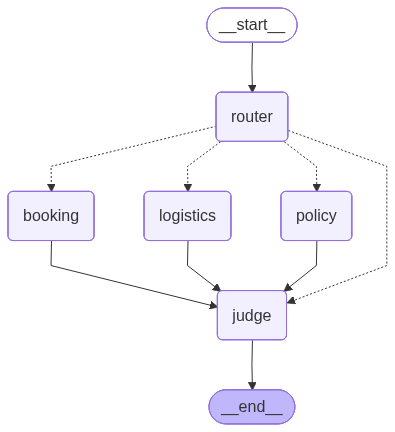

In [5]:
def route_to_specialists(state: MultiAgentState) -> list[str]:
    """Fan out to all needed specialists in parallel.

    Falls back to running both Policy and Logistics agents when the router
    detects no clear intent — matches the defensive fallback in the from-scratch
    version that uses ThreadPoolExecutor for the same pair.
    """
    targets = []
    if state["need_policy"]:
        targets.append("policy")
    if state["need_logistics"]:
        targets.append("logistics")
    if state["need_booking"]:
        targets.append("booking")
    return targets or ["policy", "logistics"]


graph = StateGraph(MultiAgentState)

graph.add_node("router", router_node)
graph.add_node("policy", policy_node)
graph.add_node("logistics", logistics_node)
graph.add_node("booking", booking_node)
graph.add_node("judge", judge_node)

graph.add_edge(START, "router")

graph.add_conditional_edges("router", route_to_specialists, {
    "policy": "policy",
    "logistics": "logistics",
    "booking": "booking",
    "judge": "judge",
})

graph.add_edge("policy", "judge")
graph.add_edge("logistics", "judge")
graph.add_edge("booking", "judge")
graph.add_edge("judge", END)

multi_agent_app = graph.compile()
print("Multi-agent graph compiled ✓")

show_graph(multi_agent_app)

## Helper: Run the System

In [6]:
import time

def run_multi_agent(query: str) -> dict:
    """Run the multi-agent system and print summary."""
    print(f"\nQuery: {query}\n")

    start = time.time()
    result = multi_agent_app.invoke({
        "query": query,
        "need_policy": False,
        "need_logistics": False,
        "need_booking": False,
        "patient_name": None,
        "patient_phone": None,
        "patient_email": None,
        "policy_result": "",
        "logistics_result": "",
        "booking_result": "",
        "final_answer": "",
        "total_tokens": 0,
    })
    elapsed = int((time.time() - start) * 1000)

    print(f"\n{'=' * 70}")
    print("SUMMARY")
    print(f"{'=' * 70}")
    print(f"Router: policy={result['need_policy']}, logistics={result['need_logistics']}, booking={result['need_booking']}")
    print(f"Total tokens: {result['total_tokens']}")
    print(f"Total time: {elapsed}ms")

    return result

## Example 1: Complex Multi-Domain Query (Policy + Logistics + Booking)

One query that triggers **all three** specialists: treatment guidelines (Policy/RAG), hospital info (Logistics/web), and the user's own appointment (Booking lookup).

In [7]:
result = run_multi_agent(
    "I'm John Silva. What are the treatment guidelines for psoriasis, "
    "which hospital in Colombo has the best dermatology department open today, "
    "and when is my appointment?"
)


Query: I'm John Silva. What are the treatment guidelines for psoriasis, which hospital in Colombo has the best dermatology department open today, and when is my appointment?


NODE: router
  policy=True, logistics=True, booking=True
  patient: John Silva

NODE: booking (lookup)

NODE: logistics (Web)

NODE: policy (RAG)

Booking 1: APT001 | Patient: John Silva | Doctor: Dr. Nimal Perera | Specialty: General Practice | Reason: Annual health checkup | Date: 2026-02-10 at 10:00 AM | Hospital: City General Hospital | Location: Building A, 2nd Floor | Status: confirmed | Notes: Fasting blood test included
Booking 2: APT005 | Patient: John Silva | Doctor: Dr. Priya Mendis | Specialty: General Practice | Reason: Skin rash consultation | Date: 2026-02-20 at 3:00 PM | Hospital: Wellness Medical Center | Location: Consultation Room 3 | Status: confirmed | Notes: Avoid applying any creams before appointment

### Treatment Guidelines for Psoriasis

Psoriasis is a chronic autoimmune condition char

## Example 2: Booking Only

In [8]:
result = run_multi_agent("I'm John Silva \u2013 when is my appointment?")


Query: I'm John Silva – when is my appointment?


NODE: router
  policy=False, logistics=False, booking=True
  patient: John Silva

NODE: booking (lookup)

Booking 1: APT001 | Patient: John Silva | Doctor: Dr. Nimal Perera | Specialty: General Practice | Reason: Annual health checkup | Date: 2026-02-10 at 10:00 AM | Hospital: City General Hospital | Location: Building A, 2nd Floor | Status: confirmed | Notes: Fasting blood test included
Booking 2: APT005 | Patient: John Silva | Doctor: Dr. Priya Mendis | Specialty: General Practice | Reason: Skin rash consultation | Date: 2026-02-20 at 3:00 PM | Hospital: Wellness Medical Center | Location: Consultation Room 3 | Status: confirmed | Notes: Avoid applying any creams before appointment

NODE: judge

Hello John Silva,

You have two upcoming appointments:

1. **Annual Health Checkup**
   - **Doctor:** Dr. Nimal Perera
   - **Date:** February 10, 2026
   - **Time:** 10:00 AM
   - **Hospital:** City General Hospital
   - **Location:** Buildi

## Example 3: Mixed (Booking + Policy)

In [9]:
result = run_multi_agent("I'm Mary Fernando. When is my appointment and what should I bring?")


Query: I'm Mary Fernando. When is my appointment and what should I bring?


NODE: router
  policy=True, logistics=False, booking=True
  patient: Mary Fernando

NODE: booking (lookup)

Booking 1: APT002 | Patient: Mary Fernando | Doctor: Dr. Sunil Silva | Specialty: General Practice | Reason: Follow-up for fever and cough | Date: 2026-02-12 at 2:30 PM | Hospital: Central Medical Clinic | Location: Ground Floor, Room 5 | Status: confirmed | Notes: Bring previous test results

NODE: policy (RAG)

Hello Mary Fernando,

To prepare for your upcoming appointment, please ensure you bring the following documents:

1. **Government-issued photo ID**
2. **Health insurance card**
3. **List of current medications** (including dosages)
4. **Previous medical records** (if you are seeing a new doctor)
5. ...
[Tokens: 740, Latency: 3777ms]

NODE: judge

Hello Mary Fernando,

Your upcoming appointment is scheduled for **February 12, 2026, at 2:30 PM** with **Dr. Sunil Silva** at the **Central Medical Cl

## Example 4: Policy Only

In [10]:
result = run_multi_agent("What are the treatment guidelines for psoriasis?")


Query: What are the treatment guidelines for psoriasis?


NODE: router
  policy=True, logistics=False, booking=False
  patient: —

NODE: policy (RAG)

The treatment guidelines for psoriasis are primarily based on the severity of the condition, the patient's overall health, and their response to previous treatments. Here’s a summary of the current treatment protocols:

### 1. **Mild to Moderate Psoriasis**
For patients with mild to moderate psorias...
[Tokens: 1090, Latency: 8462ms]

NODE: judge

### Treatment Guidelines for Psoriasis

Psoriasis is a chronic autoimmune condition characterized by the rapid growth of skin cells, leading to scaling and inflammation. Treatment guidelines vary based on the severity of the disease, the patient's overall health, and their response to previous therapies. Below is a comprehensive overview of the recommended treatment protocols:

#### 1. **Mild to Moderate Psoriasis**
For patients with mild to moderate psoriasis, the following topical treatments

## Example 5: Logistics Only

In [11]:
result = run_multi_agent("Which hospital in Colombo has the best dermatology department open today?")


Query: Which hospital in Colombo has the best dermatology department open today?


NODE: router
  policy=False, logistics=True, booking=False
  patient: —

NODE: logistics (Web)

The **360 Skin Clinic** in Colombo is highly regarded for its dermatology department and is open today. They offer advanced treatments and have a team of expert dermatologists. 

For more information, you can visit their website: [360 Skin Clinic](https://www.360bydrcherry.com/).

Additionally, the ...
[Tokens: 556, Latency: 3190ms]

NODE: judge

In Colombo, two notable hospitals with highly regarded dermatology departments that are open today are:

1. **360 Skin Clinic**: This clinic is well-known for its advanced dermatological treatments and has a team of expert dermatologists. They focus on providing personalized care and a variety of skin treatments. For more information, you can visit their website: [360 Skin Clinic](https://www.360bydrcherry.com/).

2. **Dermatology Unit of the Sri Jayewardenepura Gene

## Pattern Summary

### LangGraph vs From-Scratch

| Aspect | From-Scratch | LangGraph |
|---|---|---|
| Parallelism | `ThreadPoolExecutor` for concurrent specialist execution | Routing function returns a **list** → parallel fan-out |
| Routing | `Router` class + manual if/else dispatch | `add_conditional_edges` with multi-return routing function |
| State merge | Manual dict merging after `future.result()` | `Annotated[int, operator.add]` reducer — automatic |
| State management | Dicts passed between methods | Typed `MultiAgentState` with auto-merge across branches |
| Extensibility | Add agent class + modify orchestrator | Add node + add entry to routing list — no orchestration rewrite |

### Graph Structure (Parallel Fan-Out / Fan-In)

```
                         ┌─→ policy ────┐
START → router (fan-out) ┼─→ logistics ──┼─→ judge (fan-in) → END
                         └─→ booking ───┘
                         └─→ judge (fallback)
```

The routing function returns `["policy", "logistics"]`, `["booking"]`, or any combination.
LangGraph runs all returned nodes **in parallel** and the judge **waits for all** to complete.

### Key Design Choices

- **Parallel fan-out** mirrors the from-scratch `ThreadPoolExecutor` pattern — specialists run simultaneously
- **`Annotated[int, operator.add]`** ensures `total_tokens` from parallel branches accumulate correctly
- Specialist nodes are **pure functions** — no internal flag-checking, the graph handles routing
- The **judge** is the fan-in convergence point: all parallel paths merge there
- Adding a new specialist = add one node + one `add_edge` to judge + add to routing list

### Comparison with ReAct

| | ReAct | Multi-Agent |
|---|---|---|
| Structure | Single agent, cyclic | Multiple specialists, parallel fan-out/fan-in |
| Routing | Agent decides at each step | Router classifies once, fans out to specialists |
| Parallelism | Sequential by nature | Specialists run **in parallel** |
| Best for | Complex reasoning + multi-step | Clear domain boundaries + speed |

Multi-agent systems scale well to complex real-world applications!